In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn as sk
from sklearn.metrics import r2_score, mean_squared_error

### **Task**: Load the two datasets that you had exported and processed from GCP BigQuery

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [14]:
credit_table = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/credit_table.csv', low_memory = False)
clean_headers = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/clean_headers.csv')

# Improving Data Quality and Predictive modelling:
## **Equifax Customer credit account data**

# Tasked with starting Hypothesis to test:

Some analysts have described an interesting phenomena, where, the higher the credit card limit has been raised in the last 12 months, the more likely the customer is interested in opening a new credit card account.

**Objectives**

*   Obj1: What are the ethical concerns with such a project? How can these be mitigated?
*   Obj2: Identify the fields that are most applicable to testing this hypothesis.
*   Obj3: What data quality issues do these fields?
* Obj4 : Is there a significant relationship between the two, can it be quantified?

## Obj 1 : What are the ethical concerns with such a project? How can these be mitigated?

## **Task**: Discuss this amongst your colleagues and include here some points about risks/concerns and how you intend to mitigate them

In [18]:
clean_headers.columns

Index(['Code', 'Description'], dtype='object')

       Code                                        Description
134  LSQ469  First Applicant-All Address: Open to buy L1m [...
149  BSQ612  First Applicant-All Address: Trended Credit Ca...


## Obj2 : Identify the fields that are most applicable to testing this hypothesis


In [26]:
print(clean_headers[clean_headers.Code.isin(['BSQ612', 'LSQ469'])])

       Code                                        Description
134  LSQ469  First Applicant-All Address: Open to buy L1m [...
149  BSQ612  First Applicant-All Address: Trended Credit Ca...


## Obj 3 - What data quality issues do these fields possess?

## **Task**: How complete and duplicated are these two fields?


In [30]:
credit_table["BSQ612"].value_counts()

,count
BSQ612,
C,7983
24000,717
48000,684
60000,666
36000,633
...,...
105740,1
699700,1
61375,1


In [36]:
credit_table["BSQ612"].value_counts(dropna = False)

,count
BSQ612,
C,7983
24000,717
48000,684
60000,666
36000,633
...,...
105740,1
699700,1
61375,1


In [34]:
df1 = credit_table.dropna(subset=["BSQ612","LSQ469"])
#credit_table.duplicated().sum()
#credit_table.iloc[: , :20].info()
df1["LSQ469"].value_counts(dropna = False)

,count
LSQ469,
C,7983
G,472
M,318
2000,201
5000,196
...,...
5887,1
28805,1
17541,1


## Obj4 : Is there a significant relationship between the two, can it be quantified?

## **Task**
## 1. Calculate the Correlation coefficient of the relevant fields use df.corr()
## 2. Confirm there is a linear relationship, this with a visualisation of the fields relationship

In [22]:
credit_table.corr('BSQ612', 'LSQ469')

ValueError: could not convert string to float: 'G'

What insights can you take away from this data exploration?
- Should the dataset be scaled?
- Should we remove outliers identified inn the boxplots?
- What sort of relationship is there between the two fields?

# Building your Model

Regression model is viable but would require a domain expert or published research to verify the causal link between the two fields. Otherwise its correlation without causation.

At the very least there is a strong assoiciation between seeking higher credit limits and opening new accounts.

**Simple Linear Regression Modelling**: provided we know how much credit has increased for a customer in the last 12 months, we can reliably predict how likely the customer is interested in a new credit account. A model will mathematically define the relationship between the two fields, to demonstrate the strength of this relationship

### **Task**: Split your data into Training and Testing

In [42]:
from sklearn.model_selection import train_test_split

# Select the columns for the model
df_model = df1[['BSQ612', 'LSQ469']].apply(pd.to_numeric, errors = 'coerce').dropna()

# Define features (X) and target (y)
X = df_model[['BSQ612']]
y = df_model['LSQ469']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (52756, 1)
Testing features shape: (13189, 1)
Training target shape: (52756,)
Testing target shape: (13189,)


In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.05588898349730949
Intercept: -674.0017290457663


R-squared: 0.67
Mean Squared Error: 27753504.77


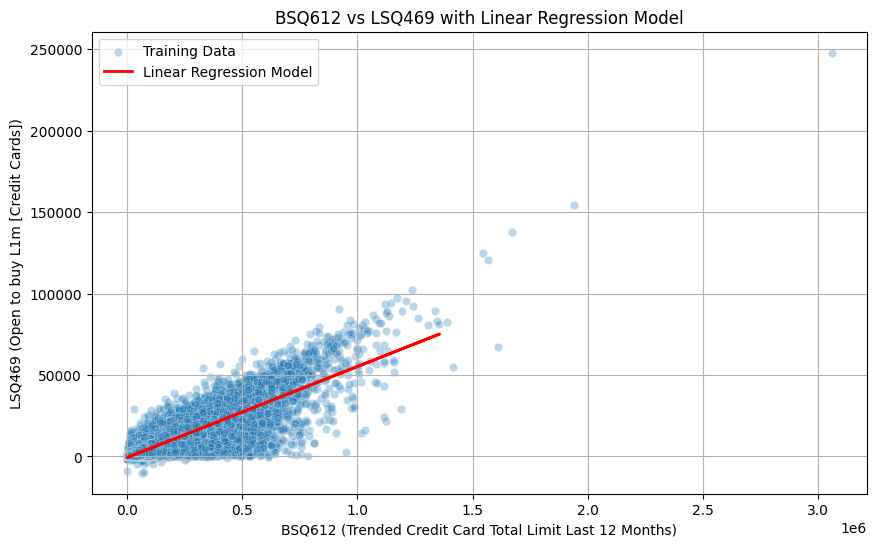

In [44]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R-squared: {r2:.2f}')
print(f'Mean Squared Error: {mse:.2f}')


# Visualize the data and the model

# Scatter plot of the training data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train['BSQ612'], y=y_train, label='Training Data', alpha=0.3)

# Plot the regression line from the trained model
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linear Regression Model')

plt.title('BSQ612 vs LSQ469 with Linear Regression Model')
plt.xlabel('BSQ612 (Trended Credit Card Total Limit Last 12 Months)')
plt.ylabel('LSQ469 (Open to buy L1m [Credit Cards])')
plt.legend()
plt.grid(True)
plt.show()

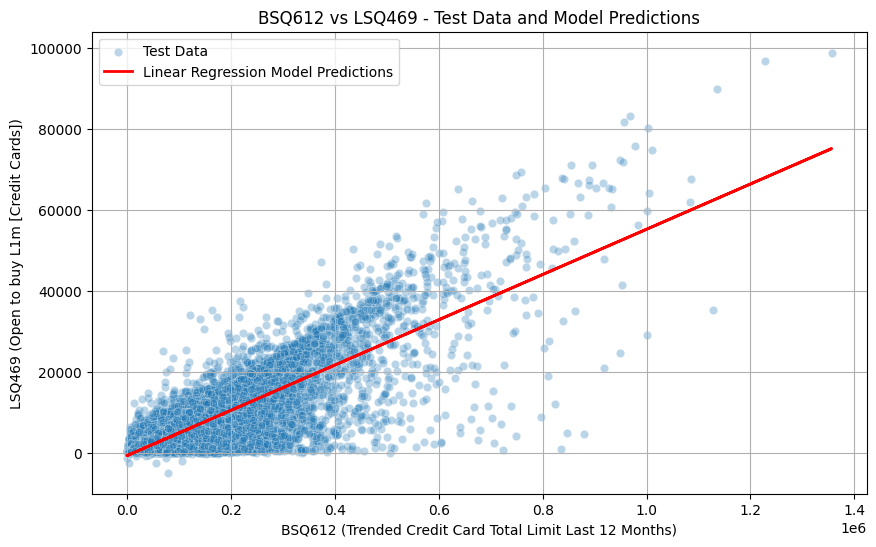

In [45]:
# Scatter plot of the test data and predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['BSQ612'], y=y_test, label='Test Data', alpha=0.3)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linear Regression Model Predictions')
plt.title('BSQ612 vs LSQ469 - Test Data and Model Predictions')
plt.xlabel('BSQ612 (Trended Credit Card Total Limit Last 12 Months)')
plt.ylabel('LSQ469 (Open to buy L1m [Credit Cards])')
plt.legend()
plt.grid(True)
plt.show()

# Perform regression and residual analysis

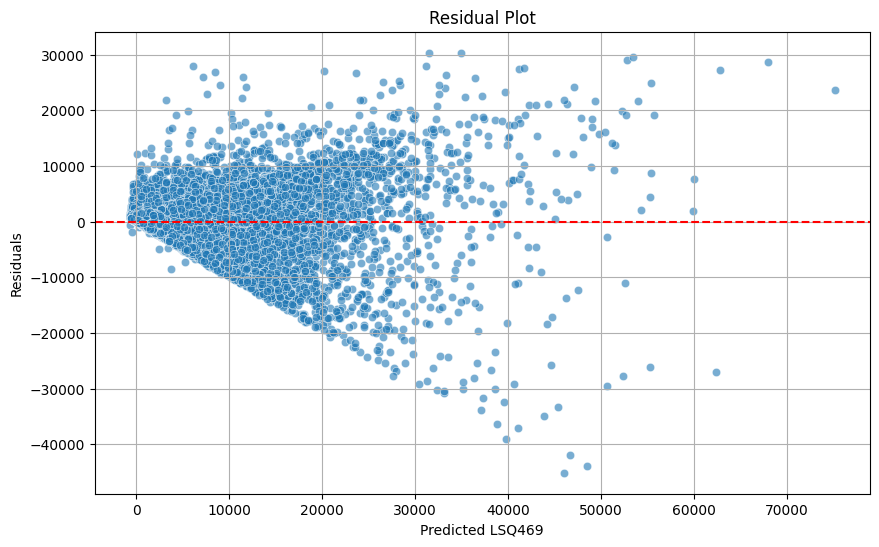

R-squared: 0.67
Mean Squared Error: 27753504.77
Coefficient: 0.05588898349730949
Intercept: -674.0017290457663


In [46]:
# Residual analysis
residuals = y_test - y_pred

# Plotting the residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted LSQ469')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


# Check for constant variance (homoscedasticity) visually from the residual plot.
# The residual plot should show random scattering of points around the zero line.

# Check for independence of residuals
# For time series data, you might use autocorrelation plots (ACF).
# For non-time series, visually inspecting the residual plot for patterns is common.

# Summary of model performance
print(f'R-squared: {r2:.2f}')
print(f'Mean Squared Error: {mse:.2f}')
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

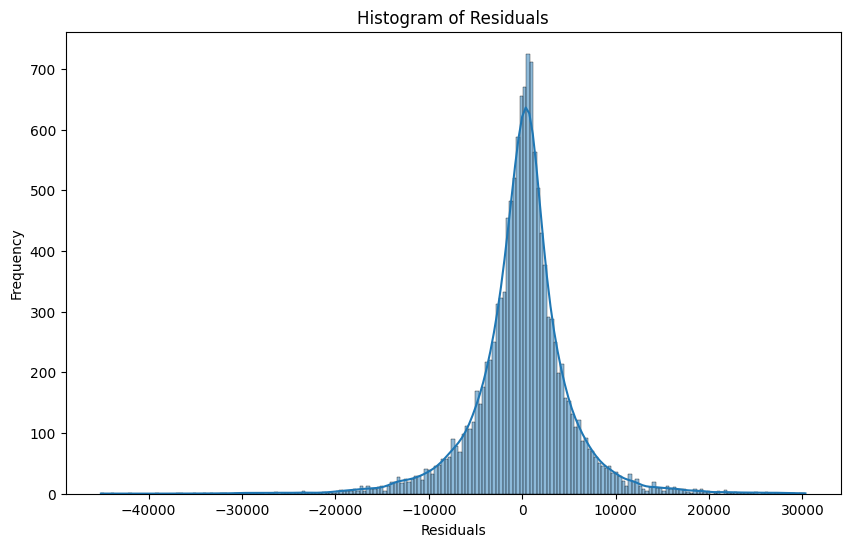

In [47]:
# Plot histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

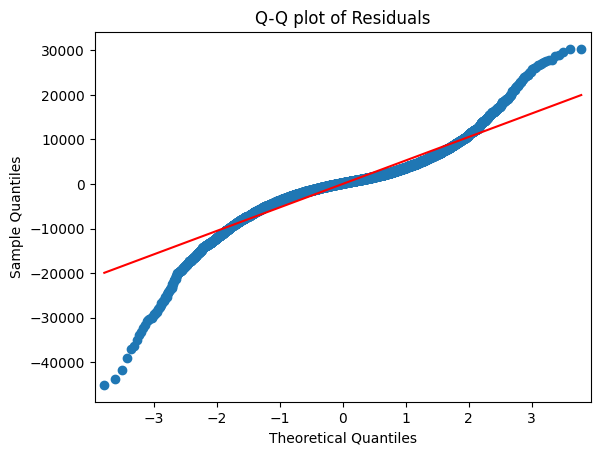

In [48]:
# Quantile-Quantile plot (Q-Q plot) of residuals
import statsmodels.api as sm
import pylab as py

sm.qqplot(residuals, line='s') # 's' for standardized line
py.title('Q-Q plot of Residuals')
py.show()

**Conclusion** - Quantified by Coefficient: 0.0556 and
Intercept: -707.438. So that for every 100 units increase of BSQ, we see a 5.5 unit increase for LSQ.  

Answered the hypothesis but there is little utility in such a predictive model. We ought to predict a KPI or some core metric that describes client outcomes.


---



## **Data Quality improvement:** Build a Regression model that can be used to infer values for incomplete columns in the dataset

## **Task:** Calculate the percentage of nulls in each column, sort them into descending order

In [66]:
# prompt: Calculate the percentage of nulls in each column, sort them into descending order


df2 = credit_table.apply(pd.to_numeric, errors = 'coerce')
null_percentages = df2.isnull().sum() / len(df2)
null_percentages.sort_values(ascending=False)

,0
CSC51,0.999679
LSQ072,0.998568
LSQ058,0.992907
CSC40,0.990431
CSC41,0.990431
...,...
EIILF52,0.000000
outref10,0.000000
efx_gbflag,0.000000
efx_weight,0.000000


In [71]:
columns_with_20_to_80_null = null_percentages[null_percentages.between(0.2,0.8)].sort_values(ascending=False).index.to_list()

## **Task:** Filter out values where the percentage of nulls is between 20% - 80%

In [73]:
df3 = df2.drop(columns_with_20_to_80_null, axis=1)

## **Task:** Create a Correlation matrix of your filtered dataframe

In [83]:
correlation = df3.corr()
correlation[(correlation > 0.3) | (correlation < -0.3)]

,outref10,efx_gbflag,efx_weight,RNISF05,RNILF05,EIILF52,EIILF51,LSQ469,LSC203,LSC204,...,SSQ16,CSC3,CSC40,CSC41,CSC51,LSQ072,LSC250,LSC350,LSC599,LSC251
outref10,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
efx_gbflag,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
efx_weight,NaN,NaN,1.000000,-0.312502,-0.323691,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RNISF05,NaN,NaN,-0.312502,1.000000,0.990799,NaN,NaN,0.405541,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RNILF05,NaN,NaN,-0.323691,0.990799,1.000000,NaN,NaN,0.406306,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LSQ072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSC250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.820689,0.495017,0.308134
LSC350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.820689,1.000000,0.408671,NaN
LSC599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.777292,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.495017,0.408671,1.000000,NaN


## **Task:** Only keep fields in the correlation matrix, that have a correlation more than 0.3 and less than -0.3

In [81]:
# prompt: drop columns that are all na

interested_in = correlation.dropna(axis=1, how='all').columns
interested_in

KeyError: 'LSQ326'

## **Note**: 'LSQ326' is identified in the solution as a good candidate for Data Quality improvment.

In [ ]:
# Blend both correlation matrix and descriptions Dataframes together.
print('LSQ326', desc_df.loc['LSQ326'].values)
LSQ326 = pd.DataFrame(cormat_filtered["LSQ326"].dropna().sort_values(ascending=False))
LSQ326_desc = LSQ326.merge(desc_df, how='inner' , left_index=True, right_index=True)
LSQ326_desc

# **Task:** Find 2 input fields that correlate and have sufficent data

In [106]:
#df2 has default values as missing
correlation_to_LSQ326 = df2[~df2.LSQ326.isnull()].corr()['LSQ326'].sort_values(ascending=False)


LSQ_null = df2[df2.LSQ326.isnull()]
population_when_LSQ326_missing = (1 - LSQ_null.isnull().sum() / len(LSQ_null)).sort_values(ascending=False)


comparison = pd.concat([correlation_to_LSQ326,population_when_LSQ326_missing],axis=1,keys=['Correlation','Population'])

comparison[(comparison.Correlation.apply(abs)>=0.3) & (comparison.Population > 0.5)].head(50)





,Correlation,Population
LSC547,0.408615,0.983378
OSQ450,0.382726,0.511482
OSQ451,0.380158,0.511482
LSC546,0.364023,0.981393


### **Note:** Selecting columns to explain the target of LSQ326, with the help of a Domain Expert who looked at Column Description, Correlation and Completeness metrics. Settled on 'OSQ450' and 'LSQ565'

In [108]:
#LSC547
#OSQ450
#OSQ451
#LSC546


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

model_data = df2.dropna(subset=['LSC547','OSQ450','OSQ451','LSC546','LSQ326'])
# Define features (X) and target (y)
X = model_data[['LSC547','OSQ450','OSQ451','LSC546']]
y = model_data['LSQ326']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


model = LinearRegression()

model.fit(X_train, y_train)
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)


Training features shape: (7748, 4)
Testing features shape: (1938, 4)
Training target shape: (7748,)
Testing target shape: (1938,)
Coefficient: [ 0.95659092 11.43898298 -0.09437424  0.52214204]
Intercept: 3.181923494874958


R-squared: 0.20
Mean Squared Error: 400.36


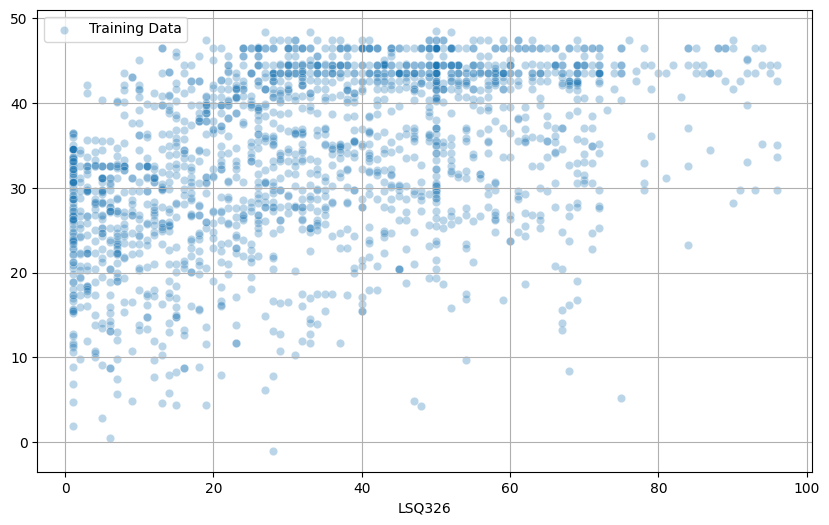

In [110]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R-squared: {r2:.2f}')
print(f'Mean Squared Error: {mse:.2f}')


# Visualize the data and the model

# Scatter plot of the training data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, label='Test Data', alpha=0.3)

# Plot the regression line from the trained model
#plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linear Regression Model')

plt.grid(True)
plt.show()

### **TASK:** With these input parameters, build a multiple linear regression model, used to infer all missing data from column LSQ327

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Select the columns for the model
df_model = df1[['BSQ612', 'LSQ469']].apply(pd.to_numeric, errors = 'coerce').dropna()

# Define features (X) and target (y)
X = df_model[['BSQ612']]
y = df_model['LSQ469']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)
model = LinearRegression()

model.fit(X_train, y_train)
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

## Model Evaluation

In [ ]:
# Residual analysis
residuals = y_test - y_pred

# Plot the residuals against the predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

# Plot a histogram of the residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

Not quite good enough fit, at least for prediction, time to retrain with other Regression modelling techniques and evaluate the best model for production

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

df_cleaner = df_clean.dropna(subset=["OSQ450", "LSQ565", "LSQ327"])

X = df_cleaner[["OSQ450", "LSQ565"]].values
y = df_cleaner["LSQ327"].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results["Linear Regression"] = {
    "R2": r2_score(y_test, y_pred_lr),
    "RMSE": mean_squared_error(y_test, y_pred_lr),
    "CV Mean R2": cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring="r2").mean()
}

# Polynomial Regression (degree=2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)
results["Polynomial Regression (deg=2)"] = {
    "R2": r2_score(y_test, y_pred_poly),
    "RMSE": mean_squared_error(y_test, y_pred_poly),
    "CV Mean R2": cross_val_score(lr_poly, X_train_poly, y_train, cv=5, scoring="r2").mean()
}

# Support Vector Regression
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
results["SVR"] = {
    "R2": r2_score(y_test, y_pred_svr),
    "RMSE": mean_squared_error(y_test, y_pred_svr),
    "CV Mean R2": cross_val_score(svr, X_train_scaled, y_train, cv=5, scoring="r2").mean()
}

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # no scaling required
y_pred_rf = rf.predict(X_test)
results["Random Forest"] = {
    "R2": r2_score(y_test, y_pred_rf),
    "RMSE": mean_squared_error(y_test, y_pred_rf),
    "CV Mean R2": cross_val_score(rf, X_train, y_train, cv=5, scoring="r2").mean()
}

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results["Gradient Boosting"] = {
    "R2": r2_score(y_test, y_pred_gb),
    "RMSE": mean_squared_error(y_test, y_pred_gb),
    "CV Mean R2": cross_val_score(gb, X_train, y_train, cv=5, scoring="r2").mean()
}

# Print results
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

## Now build an optimally performant Neural Network Regression Model using Tensorflow

In [ ]:
#!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define the model inputs and target
input = ["OSQ450", "LSQ565"]
target = 'LSQ327'

# Drop rows with missing values in the selected columns
df_numb_input_nulls = df_numb.dropna(subset=input + [target])

# Define features (X) and target (y)
X = df_numb_input_nulls[input]
y = df_numb_input_nulls[target]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add a scaler for the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate the model
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss (MSE): {loss:.4f}')
print(f'Test MAE: {mae:.4f}')

# Make predictions
y_pred_nn = model.predict(X_test_scaled).flatten()

# Evaluate R-squared for comparison
r2_nn = r2_score(y_test, y_pred_nn)
print(f'Test R-squared: {r2_nn:.4f}')

# Plot training history (Loss and MAE)
plt.figure(figsize=(12, 6))

# Plot Loss Curve - shows how well the model is learning to minimise the loss function
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# Plot MAE - shows the mean absolute error (average distance of residuals from model)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()



In [ ]:
# Plot Residuals
residuals_nn = y_test - y_pred_nn

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_nn, residuals_nn, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Neural Network Regression')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Plot the residuals against the predicted values for Neural Network
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_nn, residuals_nn, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Neural Network Regression')
plt.grid(True, alpha=0.3)
plt.show()

# Plot histogram of residuals for Neural Network
plt.figure(figsize=(10, 6))
sns.histplot(residuals_nn, kde=True)
plt.title('Histogram of Residuals (Neural Network)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Quantile-Quantile plot (Q-Q plot) of residuals for Neural Network
sm.qqplot(residuals_nn, line='s') # 's' for standardized line
py.title('Q-Q plot of Residuals (Neural Network)')
py.show()

 # Impute missing values in input features using predictions from the Neural Networked model

- This assumes you trained your model on data where input features might have had missing values and you handled them (e.g., by dropping rows, but for prediction, imputation is better if needed)
- If the original training data (X_train) didn't have missing input values because you dropped rows, you might need to calculate the mean from the full df1 or a more representative subset.

- For consistency with the training approach of dropping rows with missing inputs, we will *only* predict for rows where input features are *not* null.

- If you need to predict for rows with missing inputs, you'd need to impute here.


In [ ]:
# Identify rows in the original df1 where the target variable is null
df_to_predict = df1[df1[target].isnull()].copy()

if not df_to_predict.empty:
  # Select the input features for these rows
  X_predict = df_to_predict[input]


  # Filter rows where input features are not null for prediction
  X_predict_valid = X_predict.dropna(subset=input)
  predict_indices = X_predict_valid.index

  if not X_predict_valid.empty:
      # Scale the input features using the scaler fitted on the training data
      X_predict_scaled = scaler.transform(X_predict_valid)

      # Make predictions using the trained neural network model
      y_pred_all_nn = model.predict(X_predict_scaled).flatten()

      # Fill the missing values in the original dataframe with the predictions
      # Use .loc to ensure alignment by index
      df1.loc[predict_indices, target] = y_pred_all_nn

      print(f"Predicted and filled {len(y_pred_all_nn)} missing values in '{target}' column based on non-null input features.")
  else:
      print(f"No rows found in '{target}' with non-null input features {input} for prediction.")

else:
  print(f"No missing values found in the '{target}' column in df1. No predictions made.")

# Remaining Null count after inference via Regression NN model
print(f"\nNull count in '{target}' after filling: {df1[target].isnull().sum()}")

In [ ]:
df1.to_csv("cleaner_eqfx_customer_data.csv")
desc_df.to_csv("cleaner_headers.csv")

In [ ]:
#SAVING the Model
import pickle

# Save the trained Random Forest model
filename = 'regression_NN_LSQ327.pkl'
pickle.dump(model, open(filename, 'wb'))

# Download the model file
from google.colab import files
files.download(filename)

# ALTERNATIVELY for keeping it in the GCP ecosystem

1. Uploading Dataframe to GCP
2. Uploading Model to GCP

## 1. UPLOADING Dataframe TO GCP
2 Options
1. Big Query client, load table form dataframe
2. Big Frames package's to_gbq() streamlines process.

In [ ]:
#### OPTION 1 -- UPLOAD DF TO GCP ####

from google.cloud import bigquery

# Init BigQuery client
client = bigquery.Client()

# Define destination table
table_id = "your-project.your_dataset.your_table"

# Upload DataFrame
job = client.load_table_from_dataframe(df, table_id)
job.result()  # Wait for completion

print(f"Uploaded {job.output_rows} rows to {table_id}")

In [ ]:
#### OPTION 2 -- UPLOAD DF to GCP ####

import bigframes.pandas as bpd

bdf = bpd.from_pandas(df)
bdf.to_gbq("your-project.your_dataset.your_table", if_exists="replace")

## 2. UPLOAD MODEL TO GCP
Two options

1.   Upload the trained model (.pkl, joblib) to Google Cloud Storage
2.   Register model with Vertex AI

In [ ]:
#UPLOAD TRAINED MODEL like .pkl and .joblib to GC Storage

from google.cloud import storage
import joblib

# Save model locally
joblib.dump(model, "model.pkl")

# Upload to GCS
client = storage.Client()
bucket = client.bucket("your-gcs-bucket")
blob = bucket.blob("models/model.pkl")
blob.upload_from_filename("model.pkl")

print("Model uploaded to GCS.")


In [ ]:
# REGISTER MODEL with VERTEX AI

from google.cloud import aiplatform

aiplatform.init(project="your-project", location="europe-west4")

model = aiplatform.Model.upload(
    display_name="my-model",
    artifact_uri="gs://your-gcs-bucket/models/",
    serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.0-24:latest"
)
